# Comparison of Two Time Series of Maps
*This notebook implements the framework from the article “Foundational concepts and equations to compare two time series of maps” to quantify and visualize agreement and change between two temporal map series. Using toy data, it defines modular Python functions to compute presence‐agreement components, gains and losses, and full‐extent change metrics, and produces visualizations and exportable results for reproducible analysis.*

## 1. Environmental Setup

### 1.1 Load Libraries

In [1]:
# =============================================================================
# 1. Load Libraries
# =============================================================================
import os
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils import north_arrow

from pyproj import Transformer
from rasterio.enums import Resampling

### 1.2 Set Parameters

In [2]:
# =============================================================================
# 1. Set the parameters
# =============================================================================

# Input raster maps:
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/x"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/y"
time_points = [0, 1, 2]
class_name = "toyData"
is_binary_data = True

# Output folder
output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata2"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# NoData values
nodata_value = 255 #-32768

print("✅ Parameters successfully defined.")

✅ Parameters successfully defined.


## 2. Definition of Calculation Functions

In [4]:
# =============================================================================
# 1. Definition of all calculation functions
# =============================================================================

# -----------------------------------------------------------------------------
# 1.1 Helper function for data reading
# -----------------------------------------------------------------------------
raster_arrays = {}

def get_raster_array(year):
    """
    Reads a pair of raster files (x and y) for a given year
    or returns it from the cache if already loaded.
    """
    if year in raster_arrays:
        return raster_arrays[year]
    
    file_name = f"{class_name}{year}.tif"
    
    path_x = os.path.join(
        path_series_x,
        file_name
    )
    path_y = os.path.join(
        path_series_y,
        file_name
    )

    if (
        not os.path.exists(path_x) or
        not os.path.exists(path_y)
    ):
        print(
            f"Warning: File '{file_name}' not found for year {year}."
        )
        return None, None

    with rasterio.open(path_x) as src_x, rasterio.open(path_y) as src_y:
        array_x = src_x.read(1)
        array_y = src_y.read(1)
        raster_arrays[year] = (array_x, array_y)
        return array_x, array_y


# -----------------------------------------------------------------------------
# 1.2 Metrics calculation functions
# -----------------------------------------------------------------------------
def calculate_presence_metrics(file_x, file_y):
    """
    Calculates presence agreement metrics for a single time point.
    """
    with rasterio.open(file_x) as src_x, rasterio.open(file_y) as src_y:
        array_x = src_x.read(1)
        array_y = src_y.read(1)
        
        valid_mask = (
            (array_x != nodata_value) &
            (array_y != nodata_value)
        )
        
        presence_x = array_x[valid_mask]
        presence_y = array_y[valid_mask]
        
        hits = np.sum(np.minimum(presence_x, presence_y))
        total_x = np.sum(presence_x)
        total_y = np.sum(presence_y)
        
        hits = hits.astype(np.int64)
        total_x = total_x.astype(np.int64)
        total_y = total_y.astype(np.int64)
        
        space_difference = np.minimum(total_x, total_y) - hits
        misses = np.maximum(0, total_x - total_y)
        false_alarms = np.maximum(0, total_y - total_x)
        
        return {
            "Hit": hits,
            "Miss": misses,
            "False Alarm": false_alarms,
            "Space Difference": space_difference,
            "Total X": total_x,
            "Total Y": total_y
        }


def calculate_change_metrics(year_t, year_t_minus_1):
    """
    Calculates all gross change metrics (gains and losses)
    for a single time interval.
    """
    array_x_t, array_y_t = get_raster_array(year_t)
    array_x_t_minus_1, array_y_t_minus_1 = get_raster_array(year_t_minus_1)

    if array_x_t is None or array_x_t_minus_1 is None:
        return None

    valid_mask = (
        (array_x_t != nodata_value) &
        (array_y_t != nodata_value) &
        (array_x_t_minus_1 != nodata_value) &
        (array_y_t_minus_1 != nodata_value)
    )

    change_x = np.subtract(
        array_x_t,
        array_x_t_minus_1,
        dtype=np.int16
    )
    change_y = np.subtract(
        array_y_t,
        array_y_t_minus_1,
        dtype=np.int16
    )

    gain_x = np.maximum(0, change_x)
    gain_y = np.maximum(0, change_y)
    loss_x = np.minimum(0, change_x)
    loss_y = np.minimum(0, change_y)
    
    gain_total_x = np.sum(gain_x)
    gain_total_y = np.sum(gain_y)
    loss_total_x = np.sum(loss_x)
    loss_total_y = np.sum(loss_y)
    
    gain_hit = np.sum(np.minimum(gain_x, gain_y))
    gain_space_diff = np.minimum(gain_total_x, gain_total_y) - gain_hit
    gain_miss = np.maximum(0, gain_total_x - gain_total_y)
    gain_false_alarm = np.maximum(0, gain_total_y - gain_total_x)

    loss_hit = np.sum(np.maximum(loss_x, loss_y))
    loss_space_diff = np.maximum(loss_total_x, loss_total_y) - loss_hit
    loss_miss = np.minimum(0, loss_total_x - loss_total_y)
    loss_false_alarm = np.minimum(0, loss_total_y - loss_total_x)
    
    return {
        "Gain Hits": gain_hit,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Gain Space Difference": gain_space_diff,
        "Loss Hits": loss_hit,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
        "Loss Space Difference": loss_space_diff,
        "Gain Total X": gain_total_x,
        "Gain Total Y": gain_total_y,
        "Loss Total X": loss_total_x,
        "Loss Total Y": loss_total_y
    }


def calculate_extent_metrics(time_points_list):
    """
    Calculates gross change metrics for the entire temporal extent.
    """
    start_year, end_year = (
        time_points_list[0],
        time_points_list[-1]
    )
    
    array_x_start, array_y_start = get_raster_array(start_year)
    array_x_end, array_y_end = get_raster_array(end_year)

    if array_x_start is None or array_x_end is None:
        return None

    valid_mask = (
        (array_x_start != nodata_value) &
        (array_y_start != nodata_value) &
        (array_x_end != nodata_value) &
        (array_y_end != nodata_value)
    )

    change_x = np.subtract(
        array_x_end,
        array_x_start,
        dtype=np.int16
    )
    change_y = np.subtract(
        array_y_end,
        array_y_start,
        dtype=np.int16
    )

    gain_x = np.maximum(0, change_x)
    gain_y = np.maximum(0, change_y)
    loss_x = np.minimum(0, change_x)
    loss_y = np.minimum(0, change_y)
    
    gain_total_x = np.sum(gain_x)
    gain_total_y = np.sum(gain_y)
    loss_total_x = np.sum(loss_x)
    loss_total_y = np.sum(loss_y)

    gain_hit = np.sum(np.minimum(gain_x, gain_y))
    gain_space_diff = np.minimum(gain_total_x, gain_total_y) - gain_hit
    gain_miss = np.maximum(0, gain_total_x - gain_total_y)
    gain_false_alarm = np.maximum(0, gain_total_y - gain_total_x)

    loss_hit = np.sum(np.maximum(loss_x, loss_y))
    loss_space_diff = np.maximum(loss_total_x, loss_total_y) - loss_hit
    loss_miss = np.minimum(0, loss_total_x - loss_total_y)
    loss_false_alarm = np.minimum(0, loss_total_y - loss_total_x)
    
    return {
        "Gain Hits": gain_hit,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Gain Space Difference": gain_space_diff,
        "Loss Hits": loss_hit,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
        "Loss Space Difference": loss_space_diff
    }


def calculate_net_change_components(gross_results):
    """
    Calculates the Net Change components from Gross Change results.
    """
    if not gross_results:
        return None
        
    Ght = gross_results.get("Gain Hits", 0)
    Gut = gross_results.get("Gain Space Difference", 0)
    Gmt = gross_results.get("Gain Miss", 0)
    Gft = gross_results.get("Gain False Alarm", 0)
    Lht = gross_results.get("Loss Hits", 0)
    Lut = gross_results.get("Loss Space Difference", 0)
    Lmt = gross_results.get("Loss Miss", 0)
    Lft = gross_results.get("Loss False Alarm", 0)

    QGxt = np.maximum(0, Ght + Gut + Gmt + Lht + Lut + Lmt)
    QGyt = np.maximum(0, Ght + Gut + Gft + Lht + Lut + Lft)
    QLxt = np.minimum(0, Ght + Gut + Gmt + Lht + Lut + Lmt)
    QLyt = np.minimum(0, Ght + Gut + Gft + Lht + Lut + Lft)

    net_gain_hit = np.minimum(QGxt, QGyt)
    net_gain_miss = np.maximum(0, QGxt - QGyt)
    net_gain_false_alarm = np.maximum(0, QGyt - QGxt)
    
    net_loss_hit = np.maximum(QLxt, QLyt)
    net_loss_miss = np.minimum(0, QLxt - QLyt)
    net_loss_false_alarm = np.minimum(0, QLyt - QLxt)
    
    return {
        "Gain Hits": net_gain_hit,
        "Gain Miss": net_gain_miss,
        "Gain False Alarm": net_gain_false_alarm,
        "Loss Hits": net_loss_hit,
        "Loss Miss": net_loss_miss,
        "Loss False Alarm": net_loss_false_alarm,
        "QG_Total_X": QGxt,
        "QG_Total_Y": QGyt,
        "QL_Total_X": QLxt,
        "QL_Total_Y": QLyt
    }

print("✅ All calculation functions are defined.")

✅ All calculation functions are defined.


## 3. Execute the functions

In [5]:
# =============================================================================
# 1. Central execution of all calculations
# =============================================================================
print("Starting all data processing and calculations...")

# -----------------------------------------------------------------------------
# 1.1 Presence Hits Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Presence Hits metrics...")

results_by_time = {}
for year in time_points:
    file_name = f"{class_name}{year}.tif"
    file_x = os.path.join(path_series_x, file_name)
    file_y = os.path.join(path_series_y, file_name)
    if os.path.exists(file_x) and os.path.exists(file_y):
        results_by_time[year] = calculate_presence_metrics(file_x, file_y)

sum_results = {
    "Hit": 0,
    "Space Difference": 0,
    "Total X": 0,
    "Total Y": 0
}
for year in results_by_time:
    sum_results["Hit"] += results_by_time[year]["Hit"]
    sum_results["Space Difference"] += results_by_time[year]["Space Difference"]
    sum_results["Total X"] += results_by_time[year]["Total X"]
    sum_results["Total Y"] += results_by_time[year]["Total Y"]

sum_results["Time Difference"] = (
    np.minimum(sum_results["Total X"], sum_results["Total Y"])
    - sum_results["Hit"]
    - sum_results["Space Difference"]
)
sum_results["Miss"] = np.maximum(0, sum_results["Total X"] - sum_results["Total Y"])
sum_results["False Alarm"] = np.maximum(0, sum_results["Total Y"] - sum_results["Total X"])

print("Presence Hits calculations complete.")

# -----------------------------------------------------------------------------
# 1.2 Gross Change Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Gross Change metrics...")

change_results_by_interval = {}
time_intervals = []
for i in range(1, len(time_points)):
    year_t = time_points[i]
    year_t_minus_1 = time_points[i - 1]
    interval_label = f"{year_t_minus_1}-{year_t}"
    time_intervals.append(interval_label)
    change_results_by_interval[interval_label] = calculate_change_metrics(year_t, year_t_minus_1)

extent_results = calculate_extent_metrics(time_points)

sum_change_results = {
    "Gain Hits": 0,
    "Gain Space Difference": 0,
    "Gain Miss": 0,
    "Gain False Alarm": 0,
    "Gain Total X": 0,
    "Gain Total Y": 0,
    "Gain Time Difference": 0,
    "Loss Hits": 0,
    "Loss Space Difference": 0,
    "Loss Miss": 0,
    "Loss False Alarm": 0,
    "Loss Total X": 0,
    "Loss Total Y": 0,
    "Loss Time Difference": 0,
}
for interval in time_intervals:
    results = change_results_by_interval.get(interval)
    if results:
        for key in [
            "Gain Hits", "Gain Space Difference", "Gain Miss", "Gain False Alarm",
            "Gain Total X", "Gain Total Y",
            "Loss Hits", "Loss Space Difference", "Loss Miss", "Loss False Alarm",
            "Loss Total X", "Loss Total Y"
        ]:
            sum_change_results[key] += results[key]

# Derive time-difference terms for the sum row
sum_change_results["Gain Time Difference"] = (
    np.minimum(sum_change_results["Gain Total X"], sum_change_results["Gain Total Y"])
    - sum_change_results["Gain Hits"]
    - sum_change_results["Gain Space Difference"]
)
sum_change_results["Loss Time Difference"] = (
    np.maximum(sum_change_results["Loss Total X"], sum_change_results["Loss Total Y"])
    - sum_change_results["Loss Hits"]
    - sum_change_results["Loss Space Difference"]
)

print("Gross Change calculations complete.")

# -----------------------------------------------------------------------------
# 1.3 Net Change Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Net Change metrics...")

net_change_by_interval = {}
for interval_label, gross_results in change_results_by_interval.items():
    net_change_by_interval[interval_label] = calculate_net_change_components(gross_results)

net_extent_results = calculate_net_change_components(extent_results)

sum_net_results = {
    "QG_Total_X": 0, "QG_Total_Y": 0,
    "QL_Total_X": 0, "QL_Total_Y": 0,
    "Gain Hits": 0, "Gain Time Difference": 0, "Gain Miss": 0, "Gain False Alarm": 0,
    "Loss Hits": 0, "Loss Time Difference": 0, "Loss Miss": 0, "Loss False Alarm": 0
}
for interval, results in net_change_by_interval.items():
    if results:
        sum_net_results["QG_Total_X"] += results["QG_Total_X"]
        sum_net_results["QG_Total_Y"] += results["QG_Total_Y"]
        sum_net_results["QL_Total_X"] += results["QL_Total_X"]
        sum_net_results["QL_Total_Y"] += results["QL_Total_Y"]
        sum_net_results["Gain Hits"] += results["Gain Hits"]
        sum_net_results["Loss Hits"] += results["Loss Hits"]

# Derive time-difference terms for the net sum row
sum_net_results["Gain Time Difference"] = (
    np.minimum(sum_net_results["QG_Total_X"], sum_net_results["QG_Total_Y"])
    - sum_net_results["Gain Hits"]
)
sum_net_results["Loss Time Difference"] = (
    np.maximum(sum_net_results["QL_Total_X"], sum_net_results["QL_Total_Y"])
    - sum_net_results["Loss Hits"]
)

print("Net Change calculations complete.")
print("\n✅ All calculations are complete and results are stored in memory.")

Starting all data processing and calculations...

Calculating Presence Hits metrics...
Presence Hits calculations complete.

Calculating Gross Change metrics...
Gross Change calculations complete.

Calculating Net Change metrics...
Net Change calculations complete.

✅ All calculations are complete and results are stored in memory.


## 4. Plot the graphics

#### 4.1 Presence

##### 4.1.1 Time points


Making the graphic...


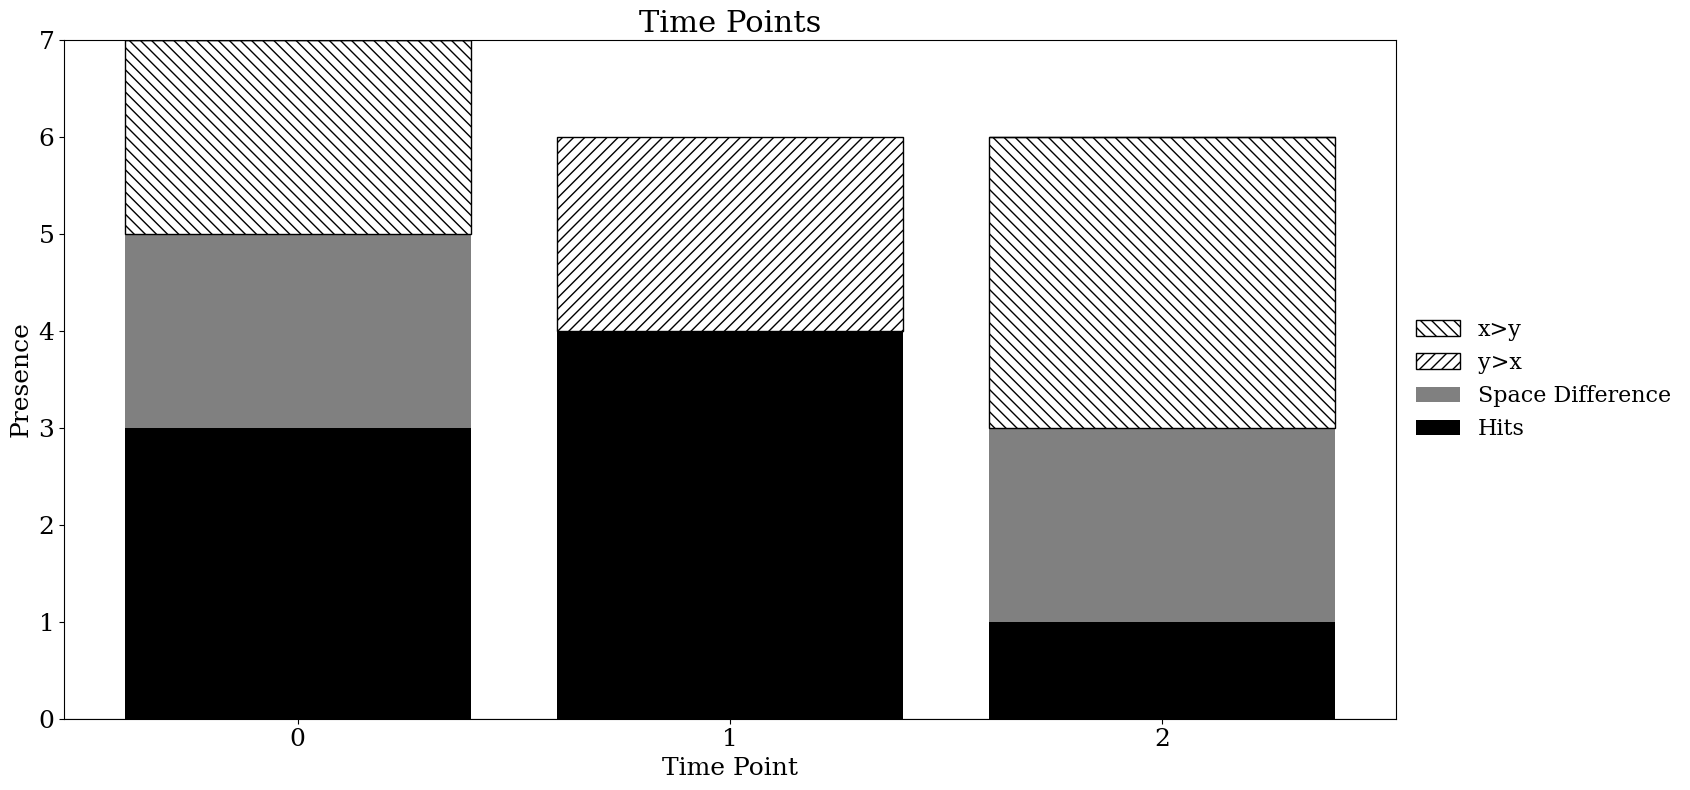


✅ Processing complete. Graphic saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata2/presence_agreement_toyData.png


In [9]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams['font.family'] = 'serif'

# ----------------------------------------------------------------------------- 
# 1.2 Data preparation
# -----------------------------------------------------------------------------
# labels = [str(tp) for tp in time_points] + ["Sum"]

# hits = [
#     results_by_time.get(tp, {}).get("Hit", 0)
#     for tp in time_points
# ] + [sum_results["Hit"]]

# space_diff = [
#     results_by_time.get(tp, {}).get("Space Difference", 0)
#     for tp in time_points
# ] + [sum_results["Space Difference"]]

# time_diff = [0] * len(time_points) + [sum_results["Time Difference"]]

# misses = [
#     results_by_time.get(tp, {}).get("Miss", 0)
#     for tp in time_points
# ] + [sum_results["Miss"]]

# false_alarms = [
#     results_by_time.get(tp, {}).get("False Alarm", 0)
#     for tp in time_points
# ] + [sum_results["False Alarm"]]

labels = [str(tp) for tp in time_points]

hits = [
    results_by_time.get(tp, {}).get("Hit", 0)
    for tp in time_points
]

space_diff = [
    results_by_time.get(tp, {}).get("Space Difference", 0)
    for tp in time_points
]

time_diff = [0] * len(time_points)

misses = [
    results_by_time.get(tp, {}).get("Miss", 0)
    for tp in time_points
]

false_alarms = [
    results_by_time.get(tp, {}).get("False Alarm", 0)
    for tp in time_points
]

# ----------------------------------------------------------------------------- 
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 8))

bottom = np.zeros(len(labels))

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# ----------------------------------------------------------------------------- 
# 1.4 Bars
# -----------------------------------------------------------------------------
ax.bar(
    labels,
    hits,
    label="Hits",
    color="black",
    bottom=bottom
)
bottom += np.array(hits)

ax.bar(
    labels,
    space_diff,
    label="Space Difference",
    color="grey",
    bottom=bottom
)
bottom += np.array(space_diff)

ax.bar(
    labels,
    time_diff,
    label="Time Difference",
    color="lightgray",
    bottom=bottom
)
bottom += np.array(time_diff)

ax.bar(
    labels,
    misses,
    label="x>y",
    color="white",
    edgecolor="black",
    hatch="\\\\\\",
    bottom=bottom
)
bottom += np.array(misses)

ax.bar(
    labels,
    false_alarms,
    label="y>x",
    color="white",
    edgecolor="black",
    hatch="///",
    bottom=bottom
)

# ----------------------------------------------------------------------------- 
# 1.5 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()

order = [
    "x>y",
    "y>x",
    # "Time Difference",
    "Space Difference",
    "Hits"
]

legend_dict = dict(zip(labels_list, handles))

ordered_handles = [legend_dict[label] for label in order]

ax.legend(
    ordered_handles,
    order,
    loc="center left",
    fontsize=16,
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

# ----------------------------------------------------------------------------- 
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Time Points",
    fontsize=22
)

ax.set_xlabel(
    "Time Point",
    fontsize=18
)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=18,
    rotation=0
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=18,
    rotation=0
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.set_ylim(
#     0,
#     18
# )
ax.set_ylabel(
    "Presence",
    fontsize=18
)

# Option 2: For large values (divide by 1 million)
# def millions_formatter(y, pos):
#     return f"{y / 1_000_000:.0f}"

# ax.yaxis.set_major_formatter(
#     FuncFormatter(millions_formatter)
# )
# ax.set_ylabel(
#     "Presence (million pixels)",
#     fontsize=18
# )

# ax.set_ylim(
#     0,
#     30_000_000
# )

# Option 3: For large values (divide by 1 thousand)
# def thousands_formatter(y, pos):
#     return f"{y / 1_000:.0f}"

# ax.yaxis.set_major_formatter(
#     FuncFormatter(thousands_formatter)
# )
# ax.set_ylabel(
#     "Presence",
#     fontsize=18
# )

# =============================================================================
# 1.7 Save figure
# =============================================================================
plt.tight_layout(rect=[0, 0, 0.85, 1])

output_filename = f"presence_agreement_{class_name}.png"
final_chart_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_chart_path,
    dpi=300
)

plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_chart_path}")

##### 4.1.2 Sum


Making the graphic...


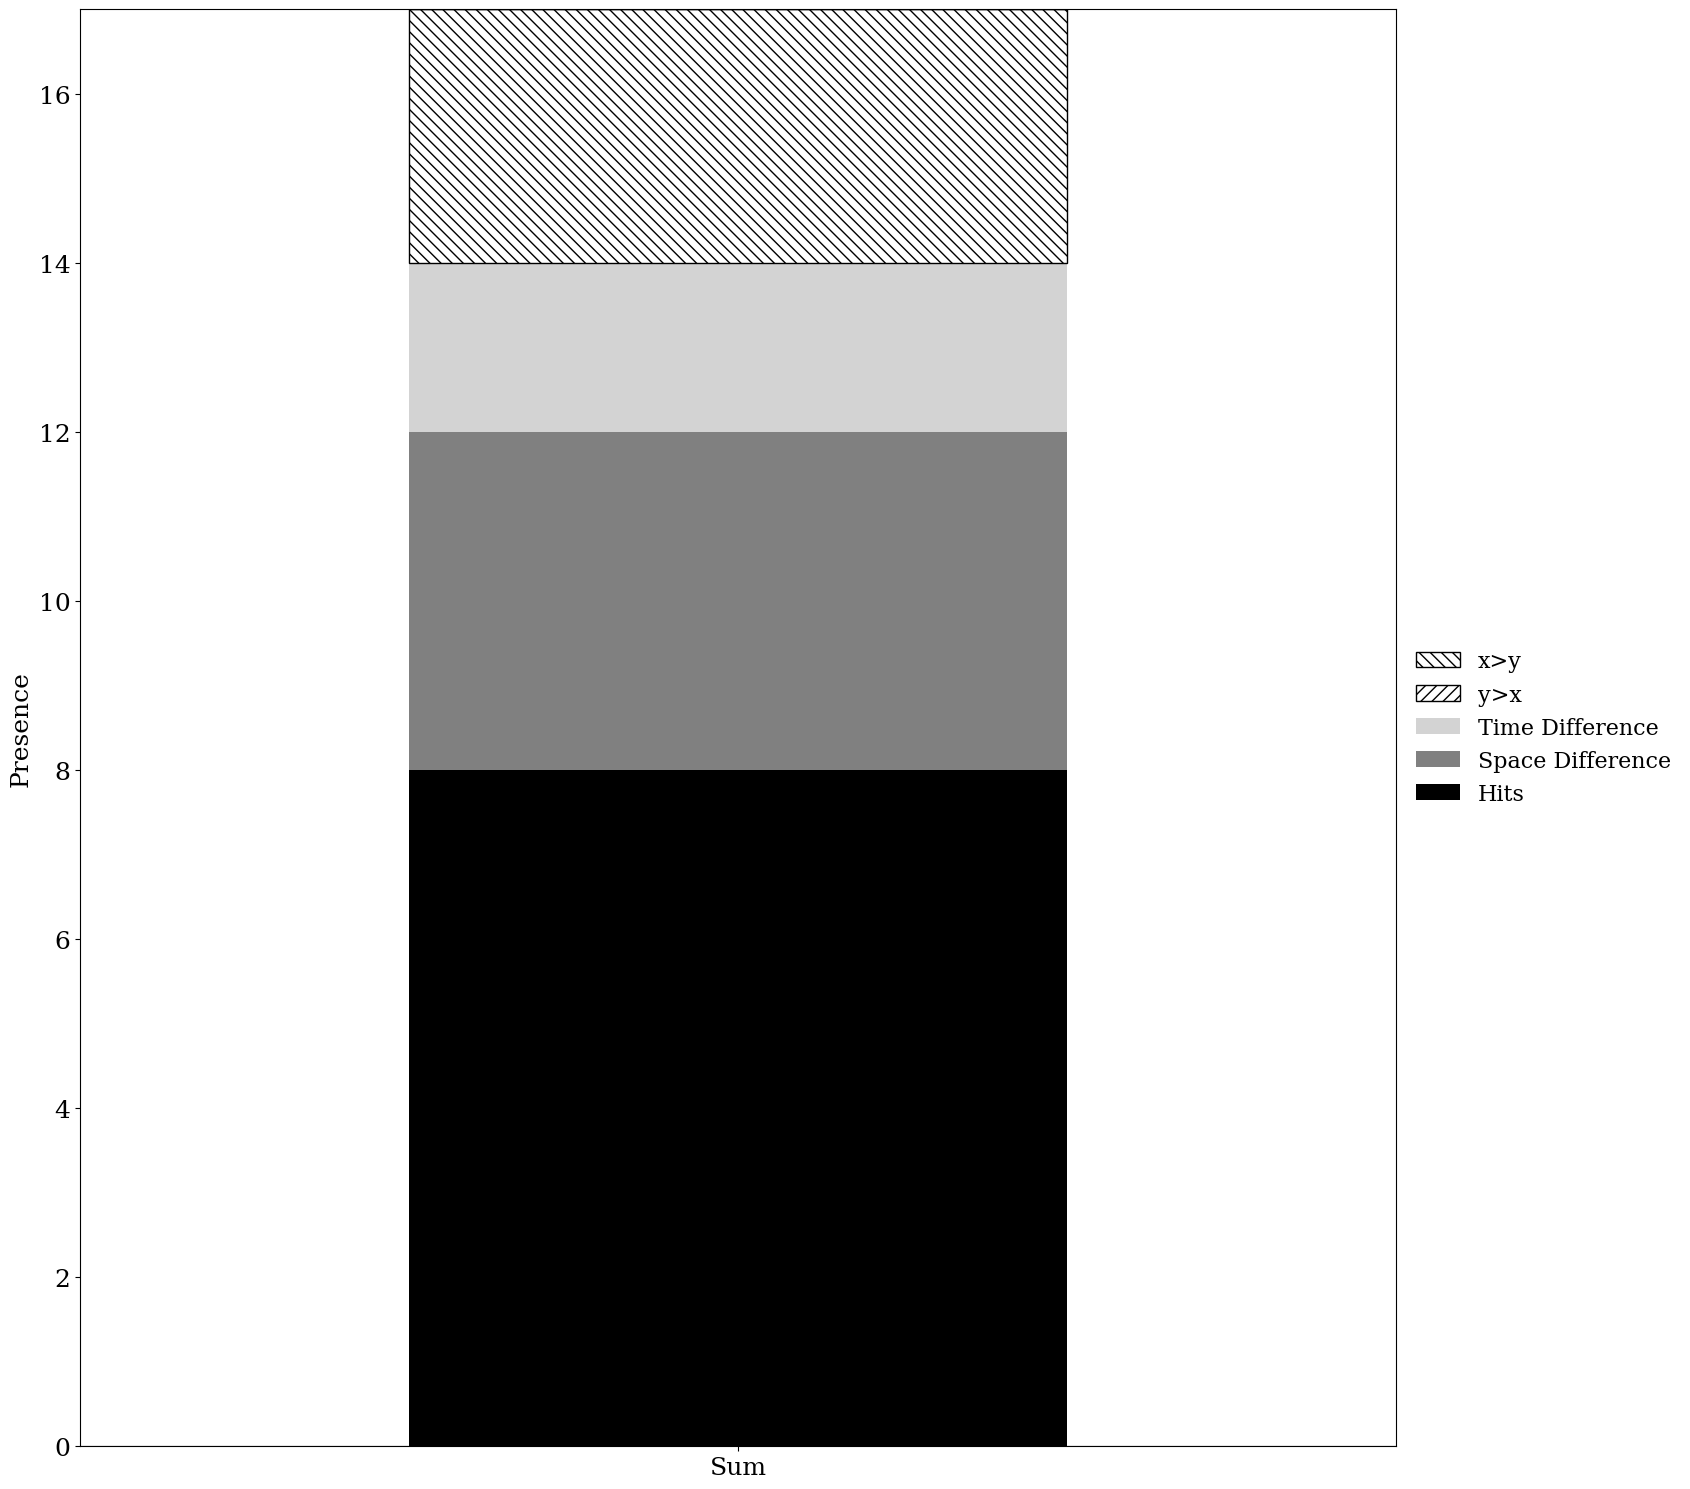


✅ Processing complete. Graphic saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata2/presence_agreement_toyData.png


In [10]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams['font.family'] = 'serif'

# ----------------------------------------------------------------------------- 
# 1.2 Data preparation
# -----------------------------------------------------------------------------
labels = ["Sum"]

hits = [sum_results["Hit"]]

space_diff = [sum_results["Space Difference"]]

time_diff = [sum_results["Time Difference"]]

misses = [sum_results["Miss"]]

false_alarms = [sum_results["False Alarm"]]

# ----------------------------------------------------------------------------- 
# 1.3 Figure setup
# -----------------------------------------------------------------------------
# fig, ax = plt.subplots(figsize=(20, 8))
fig, ax = plt.subplots(figsize=(20, 15))

x = np.array([0])

bottom = np.zeros(len(labels))

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# ----------------------------------------------------------------------------- 
# 1.4 Bars
# -----------------------------------------------------------------------------
bar_width = 0.2

ax.bar(
    x,
    hits,
    label="Hits",
    color="black",
    bottom=bottom,
    width=bar_width
)
bottom += np.array(hits)

ax.bar(
    x,
    space_diff,
    label="Space Difference",
    color="grey",
    bottom=bottom,
    width=bar_width
)
bottom += np.array(space_diff)

ax.bar(
    x,
    time_diff,
    label="Time Difference",
    color="lightgray",
    bottom=bottom,
    width=bar_width
)
bottom += np.array(time_diff)

ax.bar(
    x,
    misses,
    label="x>y",
    color="white",
    edgecolor="black",
    hatch="\\\\\\",
    bottom=bottom,
    width=bar_width
)
bottom += np.array(misses)

ax.bar(
    x,
    false_alarms,
    label="y>x",
    color="white",
    edgecolor="black",
    hatch="///",
    bottom=bottom,
    width=bar_width
)

ax.set_xticks(x)
ax.set_xticklabels(["Sum"])
ax.set_xlim(-0.2, 0.2)


# ----------------------------------------------------------------------------- 
# 1.5 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()

order = [
    "x>y",
    "y>x",
    "Time Difference",
    "Space Difference",
    "Hits"
]

legend_dict = dict(zip(labels_list, handles))

ordered_handles = [legend_dict[label] for label in order]

ax.legend(
    ordered_handles,
    order,
    loc="center left",
    fontsize=16,
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

# ----------------------------------------------------------------------------- 
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
# ax.set_title(
#     "Time Points and Sum",
#     fontsize=22
# )

# ax.set_xlabel(
#     "Time Point",
#     fontsize=18
# )

ax.tick_params(
    axis="x",
    which="major",
    labelsize=18,
    rotation=0
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=18,
    rotation=0
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.set_ylim(
#     0,
#     18
# )
ax.set_ylabel(
    "Presence",
    fontsize=18
)

# Option 2: For large values (divide by 1 million)
# def millions_formatter(y, pos):
#     return f"{y / 1_000_000:.0f}"

# ax.yaxis.set_major_formatter(
#     FuncFormatter(millions_formatter)
# )
# ax.set_ylabel(
#     "Presence (million pixels)",
#     fontsize=18
# )

# ax.set_ylim(
#     0,
#     30_000_000
# )

# Option 3: For large values (divide by 1 thousand)
# def thousands_formatter(y, pos):
#     return f"{y / 1_000:.0f}"

# ax.yaxis.set_major_formatter(
#     FuncFormatter(thousands_formatter)
# )
# ax.set_ylabel(
#     "Presence",
#     fontsize=18
# )

# =============================================================================
# 1.7 Save figure
# =============================================================================
plt.tight_layout(rect=[0, 0, 0.85, 1])

output_filename = f"presence_agreement_{class_name}.png"
final_chart_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_chart_path,
    dpi=300
)

plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_chart_path}")

#### 4.2 Gross Change

##### 4.2.1 Time Intervals


Making the graphic...


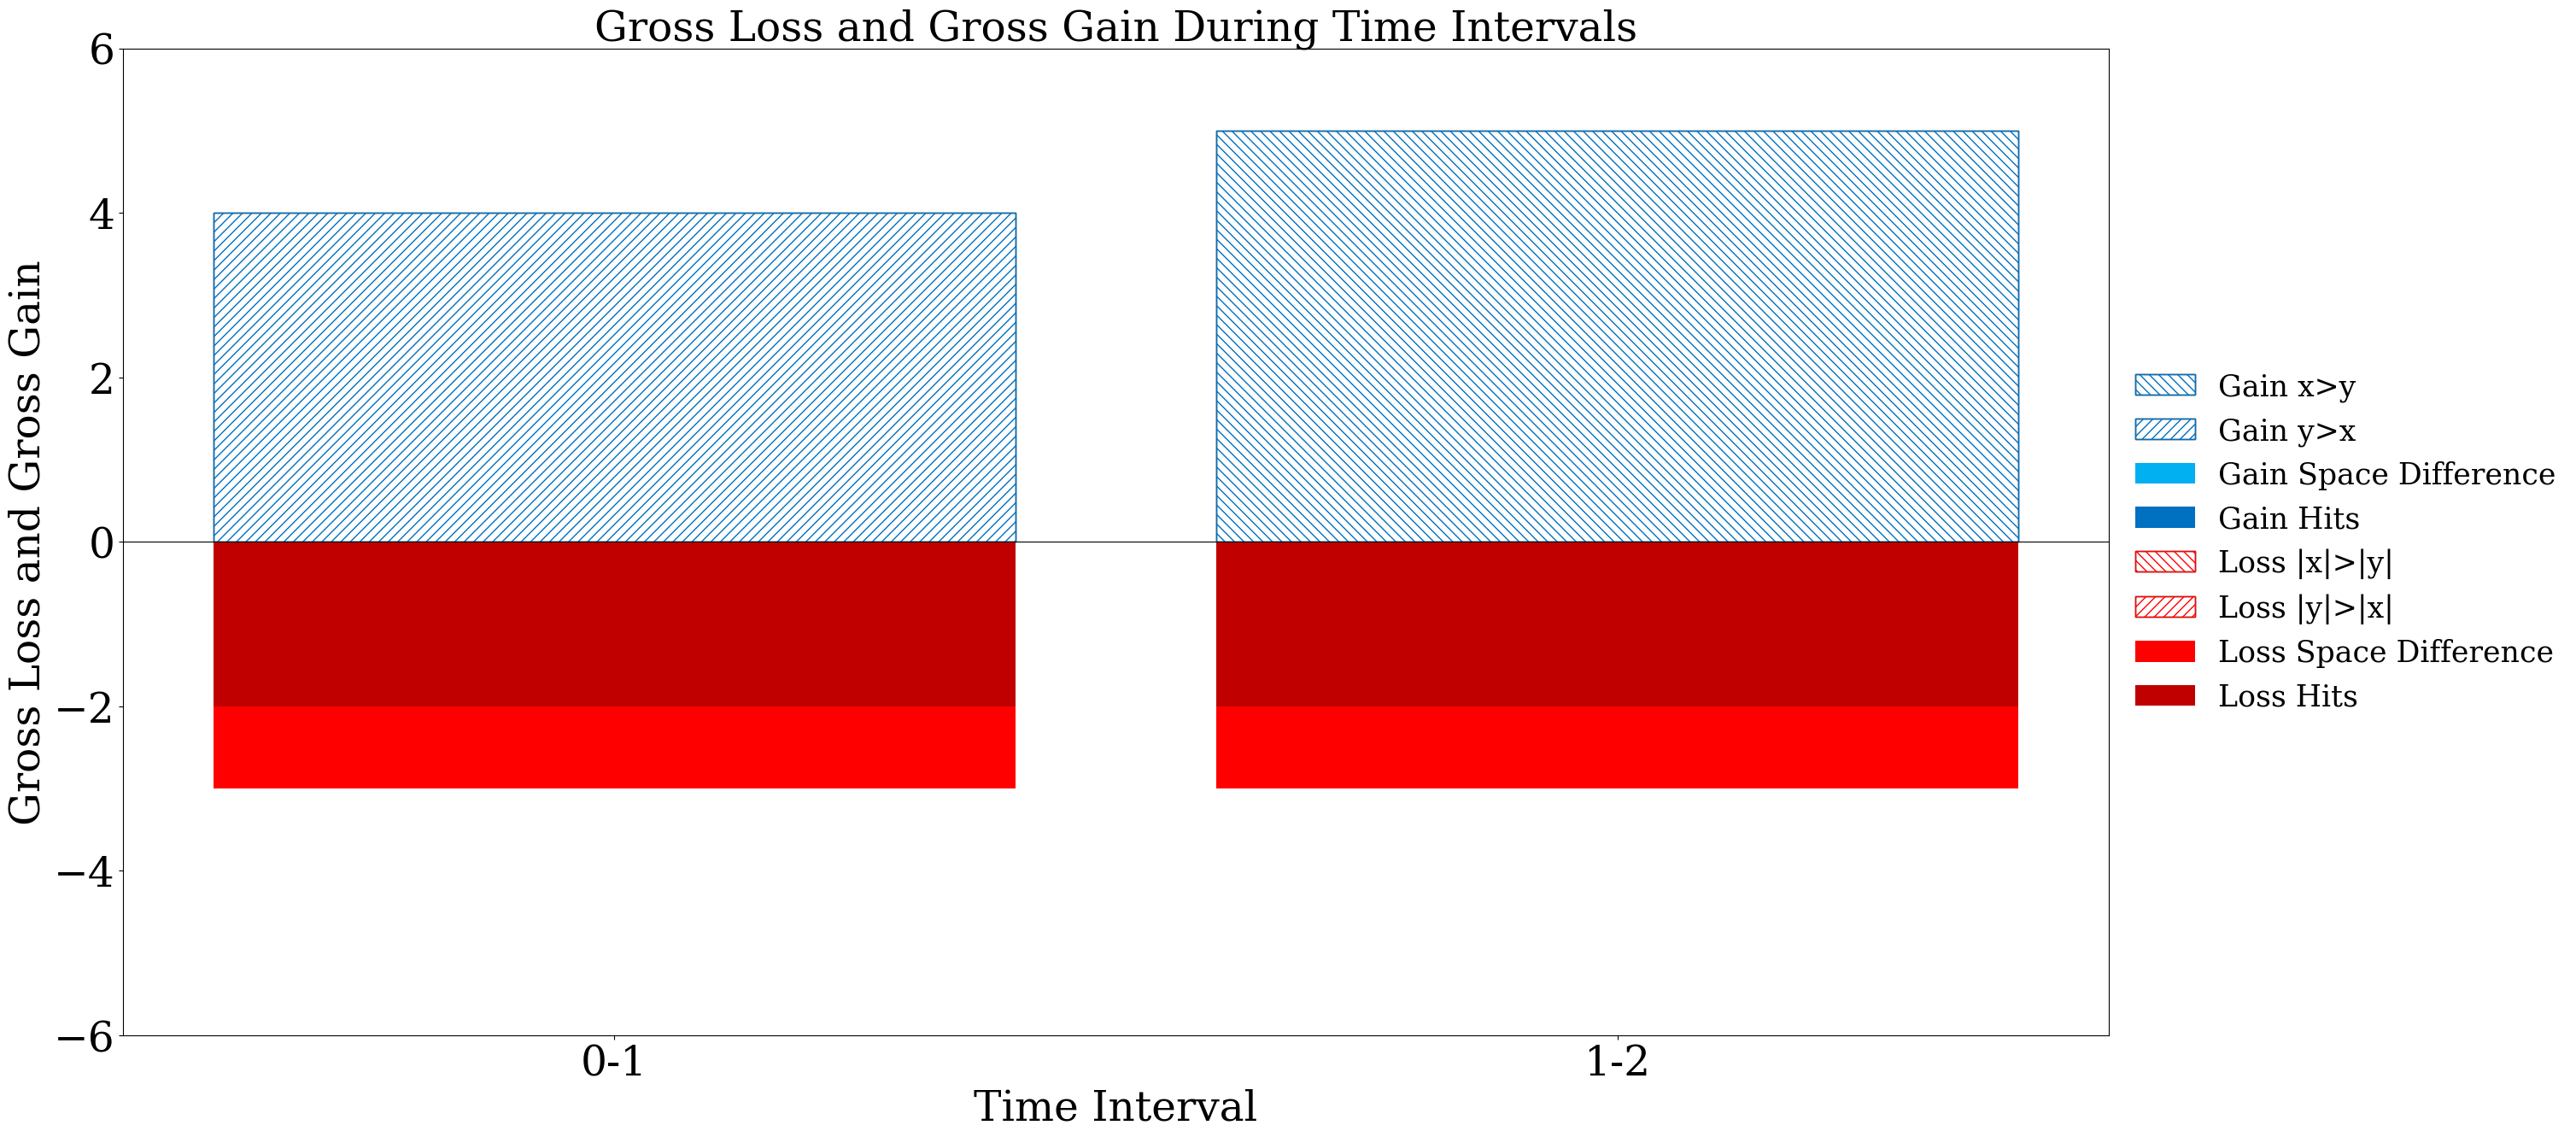


✅ Processing complete. Graphic saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata2/gross_change_toyData.png


In [11]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
# plot_data_list = []

# for interval in time_intervals:
#     row_data = change_results_by_interval.get(interval, {})
#     row_data["Interval"] = interval
#     plot_data_list.append(row_data)

# sum_row_gross = sum_change_results.copy()
# sum_row_gross["Interval"] = "Sum"
# plot_data_list.append(sum_row_gross)

# extent_row_gross = extent_results.copy()
# extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
# plot_data_list.append(extent_row_gross)

# df_plot = pd.DataFrame(plot_data_list).set_index("Interval").fillna(0)
# labels = df_plot.index.tolist()

# gain_colors = {
#     "Hits": "#0070C0",
#     "Space Difference": "#00B0F0",
#     "Time Difference": "#BDD7EE",
#     "Miss": "white",
#     "False Alarm": "white"
# }
# loss_colors = {
#     "Hits": "#C00000",
#     "Space Difference": "#FF0000",
#     "Time Difference": "#FF9696",
#     "Miss": "white",
#     "False Alarm": "white"
# }
# gain_hatch_color = "#0070C0"
# loss_hatch_color = "#FF0000"

plot_data_list = []

for interval in time_intervals:
    row_data = change_results_by_interval.get(interval, {})
    row_data["Interval"] = interval
    plot_data_list.append(row_data)

# continua calculando sum e extent (se precisar em tabela/export)
sum_row_gross = sum_change_results.copy()
sum_row_gross["Interval"] = "Sum"
plot_data_list.append(sum_row_gross)

extent_row_gross = extent_results.copy()
extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
plot_data_list.append(extent_row_gross)

# cria dataframe
df_plot = pd.DataFrame(plot_data_list).set_index("Interval").fillna(0)

# remove as duas últimas linhas apenas do gráfico
extent_label = f"{time_points[0]}-{time_points[-1]}"
df_plot = df_plot.drop(["Sum", extent_label], errors="ignore")

labels = df_plot.index.tolist()

gain_colors = {
    "Hits": "#0070C0",
    "Space Difference": "#00B0F0",
    "Time Difference": "#BDD7EE",
    "Miss": "white",
    "False Alarm": "white"
}
loss_colors = {
    "Hits": "#C00000",
    "Space Difference": "#FF0000",
    "Time Difference": "#FF9696",
    "Miss": "white",
    "False Alarm": "white"
}
gain_hatch_color = "#0070C0"
loss_hatch_color = "#FF0000"

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(30, 15)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# -----------------------------------------------------------------------------
# 1.4 Bars — Gains
# -----------------------------------------------------------------------------

bottom_gain = np.zeros(len(labels))

for comp in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    disp = "x>y" if comp == "Miss" else ("y>x" if comp == "False Alarm" else comp)
    col = f"Gain {comp}"
    data = df_plot[col].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Gain {disp}",
            color=gain_colors[comp],
            bottom=bottom_gain,
            edgecolor="none"
        )
    bottom_gain += data

# -----------------------------------------------------------------------------
# 1.5 Bars — Losses
# -----------------------------------------------------------------------------
bottom_loss = np.zeros(len(labels))

for comp in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    disp = "|x|>|y|" if comp == "Miss" else ("|y|>|x|" if comp == "False Alarm" else comp)
    col = f"Loss {comp}"
    data = df_plot[col].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Loss {disp}",
            color=loss_colors[comp],
            bottom=bottom_loss,
            edgecolor="none"
        )
    bottom_loss += data

# -----------------------------------------------------------------------------
# 1.6 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="\\\\\\")
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="///")
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="\\\\\\")
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="///")
)

order = [
    "Gain x>y",
    "Gain y>x",
    # "Gain Time Difference",
    "Gain Space Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    # "Loss Time Difference",
    "Loss Space Difference",
    "Loss Hits"
]

ordered_handles = [legend_dict.get(label) for label in order if label in legend_dict]
ordered_labels  = [label for label in order if label in legend_dict]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=25,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

# -----------------------------------------------------------------------------
# 1.7 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Gross Loss and Gross Gain During Time Intervals",
    fontsize=35
)
ax.set_xlabel(
    "Time Interval",
    fontsize=35
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=35,
    rotation=0
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=35,
    # rotation=90
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
ax.autoscale(enable=False, axis="y")
ax.set_ylim(
    -6,
     6
)
ax.margins(y=0)
# ax.set_yticks(np.arange(-8, 14 + 1, 2))
ax.set_ylabel(
    "Gross Loss and Gross Gain",
    fontsize=35
)

# Option 2: For large values (divide by 1 million)
# def millions_formatter(y, pos):
#     return f"{y / 1_000_000:.0f}"
# ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
# # ax.set_ylim(
# #     -2_000_000,
# #      2_000_000
# # )
# ax.set_ylabel(
#     "Gross Loss and Gross Gain (million pixels)",
#     fontsize=35
# )

# Option 3: For large values (divide by 1 thousand)
# def thousands_formatter(y, pos):
#     return f"{y / 1_000:.0f}"
# ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
# ax.set_ylim(-900_000, 900_000)
# ax.set_ylabel(
#     "Gross Loss and Gross Gain (thousand pixels)",
#     fontsize=20
# )

# =============================================================================
# 1.8 Save figure
# =============================================================================
output_filename = f"gross_change_{class_name}.png"
final_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_path}")

##### 4.2.2 Bar plot of Sum and Extent


Plotting only 'Sum' and 'Extent' bars...


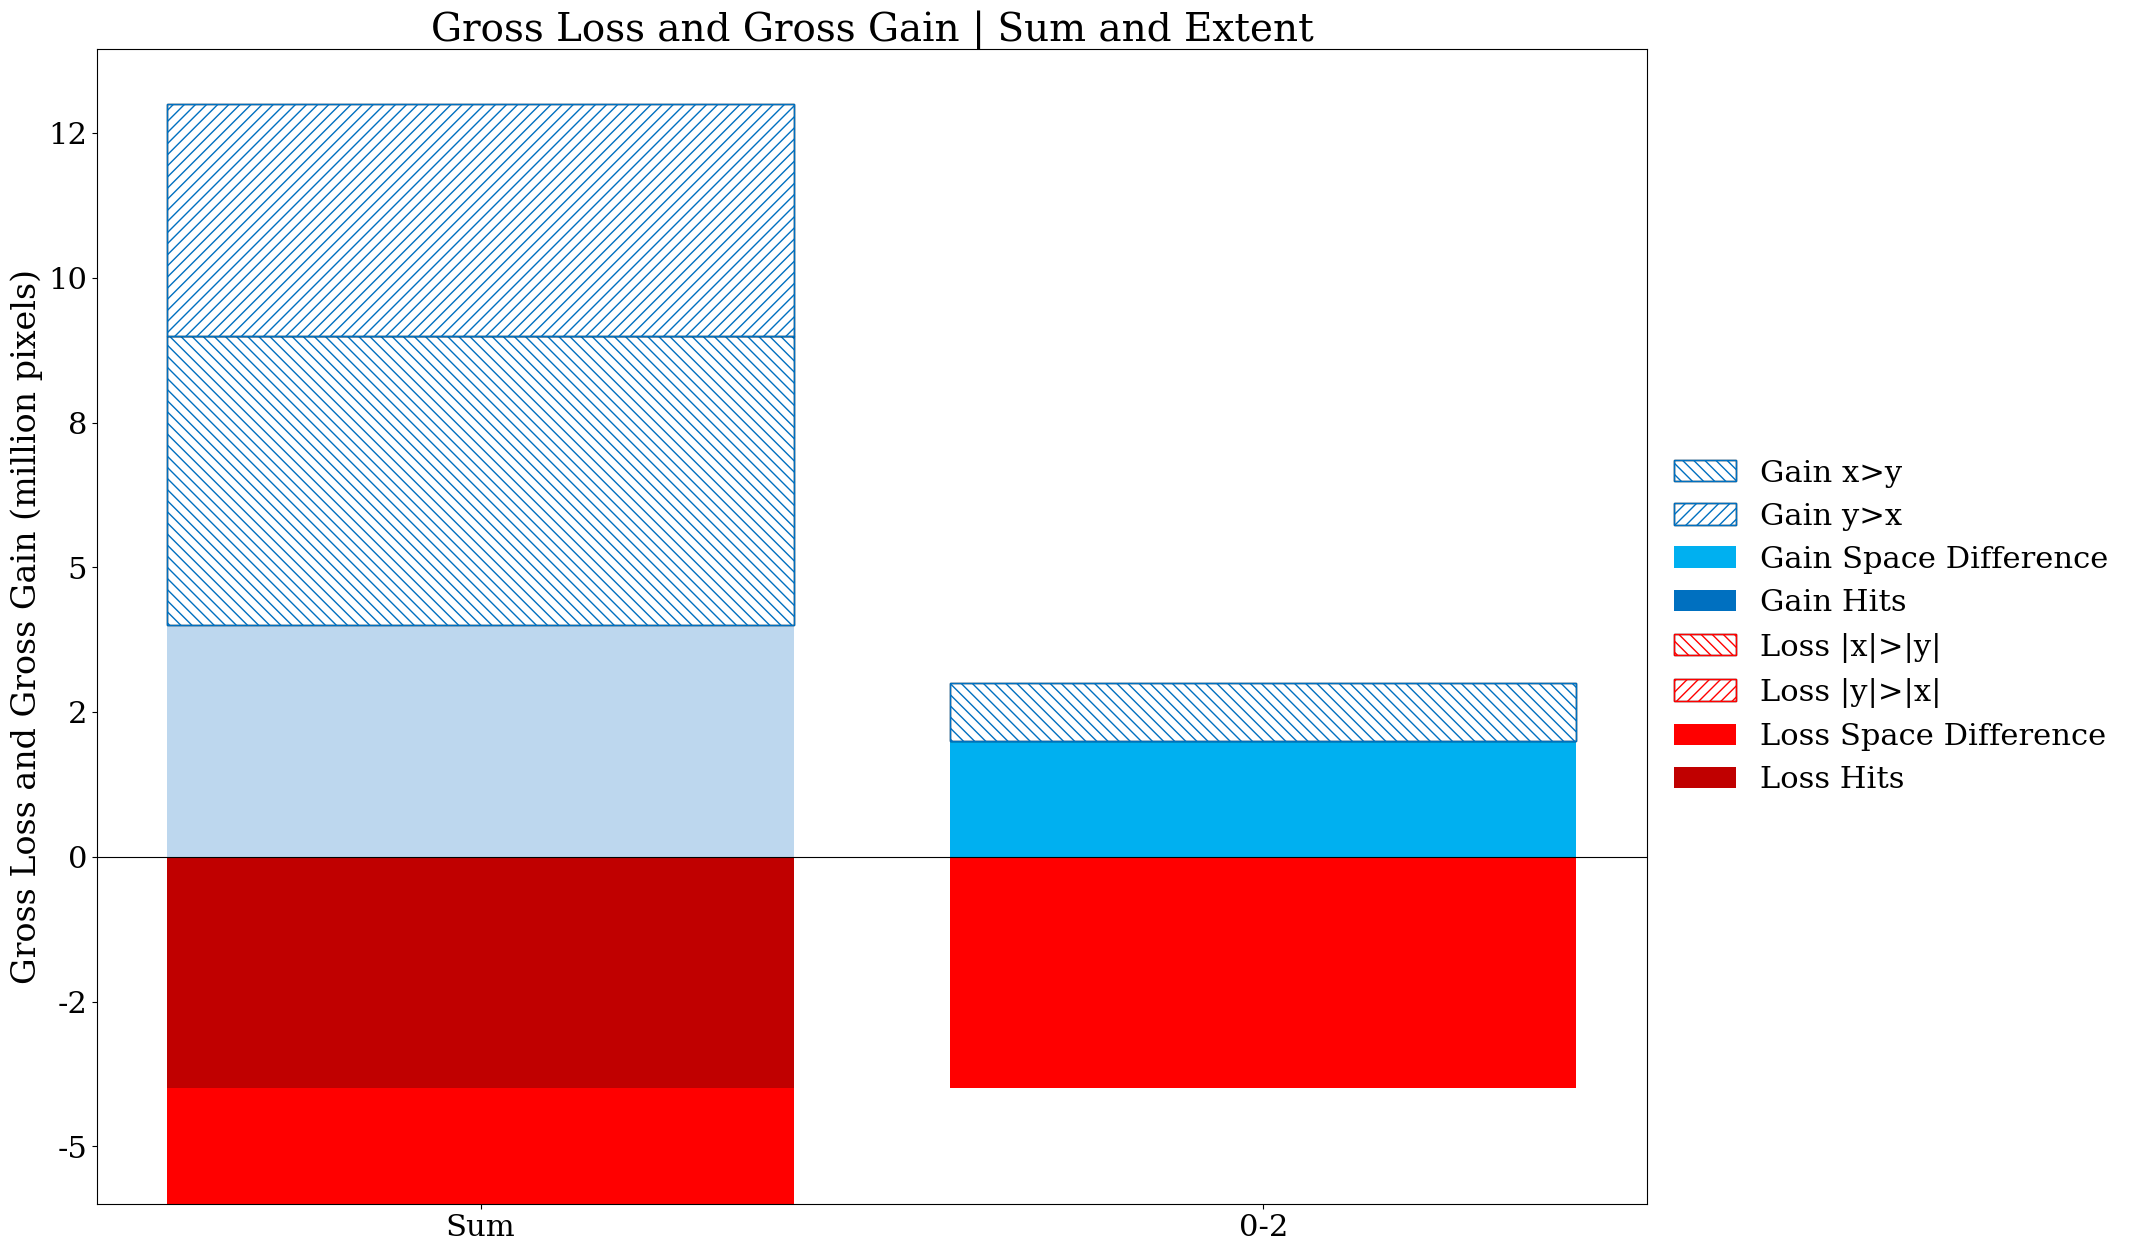


✅ Plot saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata2/gross_change_sum_extent_toyData.png


In [12]:
# =============================================================================
# Plot ONLY "Sum" and "Extent" bars (same style as main chart)
# =============================================================================
print("\nPlotting only 'Sum' and 'Extent' bars...")

# --- defaults in case they were not defined earlier ---
if 'gain_colors' not in globals():
    gain_colors = {
        "Hits": "#0070C0",
        "Space Difference": "#00B0F0",
        "Time Difference": "#BDD7EE",
        "Miss": "white",
        "False Alarm": "white"
    }
if 'loss_colors' not in globals():
    loss_colors = {
        "Hits": "#C00000",
        "Space Difference": "#FF0000",
        "Time Difference": "#FF9696",
        "Miss": "white",
        "False Alarm": "white"
    }
gain_hatch_color = globals().get("gain_hatch_color", "#0070C0")
loss_hatch_color = globals().get("loss_hatch_color", "#FF0000")

# Labels for the two summary bars
extent_label = f"{time_points[0]}-{time_points[-1]}"

# Build dataframe with only Sum and Extent
sum_row_gross = dict(sum_change_results)
sum_row_gross["Interval"] = "Sum"

extent_row_gross = dict(extent_results)
extent_row_gross["Interval"] = extent_label

df_plot_se = pd.DataFrame([sum_row_gross, extent_row_gross]).set_index("Interval").fillna(0)
labels_se = df_plot_se.index.tolist()

# Figure
fig, ax = plt.subplots(figsize=(20, 15))
ax.axhline(0, color="black", linewidth=0.8)
mpl.rcParams["font.family"] = "serif"

# ----- Gains (stacked, positive) -----
bottom_gain = np.zeros(len(labels_se))
for comp in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    disp = "x>y" if comp == "Miss" else ("y>x" if comp == "False Alarm" else comp)
    col = f"Gain {comp}"
    data = df_plot_se[col].values if col in df_plot_se.columns else np.zeros(len(labels_se))

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"
        ax.bar(labels_se, plot_data, label=f"Gain {disp}", color="white",
               bottom=bottom_gain, edgecolor="black")
        ax.bar(labels_se, plot_data, color="none", bottom=bottom_gain,
               edgecolor=gain_hatch_color, hatch=hatch)
    else:
        ax.bar(labels_se, data, label=f"Gain {disp}",
               color=gain_colors.get(comp, "#cccccc"),
               bottom=bottom_gain, edgecolor="none")
    bottom_gain += data

# ----- Losses (stacked, negative values expected in df) -----
bottom_loss = np.zeros(len(labels_se))
for comp in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    disp = "|x|>|y|" if comp == "Miss" else ("|y|>|x|" if comp == "False Alarm" else comp)
    col = f"Loss {comp}"
    data = df_plot_se[col].values if col in df_plot_se.columns else np.zeros(len(labels_se))

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"
        ax.bar(labels_se, plot_data, label=f"Loss {disp}", color="white",
               bottom=bottom_loss, edgecolor="black")
        ax.bar(labels_se, plot_data, color="none", bottom=bottom_loss,
               edgecolor=loss_hatch_color, hatch=hatch)
    else:
        ax.bar(labels_se, data, label=f"Loss {disp}",
               color=loss_colors.get(comp, "#f2aaaa"),
               bottom=bottom_loss, edgecolor="none")
    bottom_loss += data

# ----- Legend (same ordering you used, sem Time Difference nos grupos compostos) -----
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="\\\\\\")
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="///")
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="\\\\\\")
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="///")
)

order = [
    "Gain x>y", "Gain y>x",
    "Gain Space Difference", "Gain Hits",
    "Loss |x|>|y|", "Loss |y|>|x|",
    "Loss Space Difference", "Loss Hits"
]
ordered_handles = [legend_dict.get(label) for label in order if label in legend_dict]
ordered_labels  = [label for label in order if label in legend_dict]

ax.legend(handles=ordered_handles, labels=ordered_labels,
          loc="center left", fontsize=22, bbox_to_anchor=(1, 0.5),
          frameon=False, alignment="left")

# ----- Axes & title -----
ax.set_title("Gross Loss and Gross Gain | Sum and Extent", fontsize=28)
# ax.set_xlabel("Summary", fontsize=24)
ax.tick_params(axis="x", which="major", labelsize=22)
ax.tick_params(axis="y", which="major", labelsize=22)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y/1:.0f}"))
ax.set_ylabel("Gross Loss and Gross Gain (million pixels)", fontsize=24)

# ----- Save -----
out_name = f"gross_change_sum_extent_{class_name}.png"
final_path = os.path.join(output_path, out_name)
plt.savefig(final_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✅ Plot saved as: {final_path}")

#### 4.3 Net Change

##### 4.3.1 Time Intervals


Making the graphic...


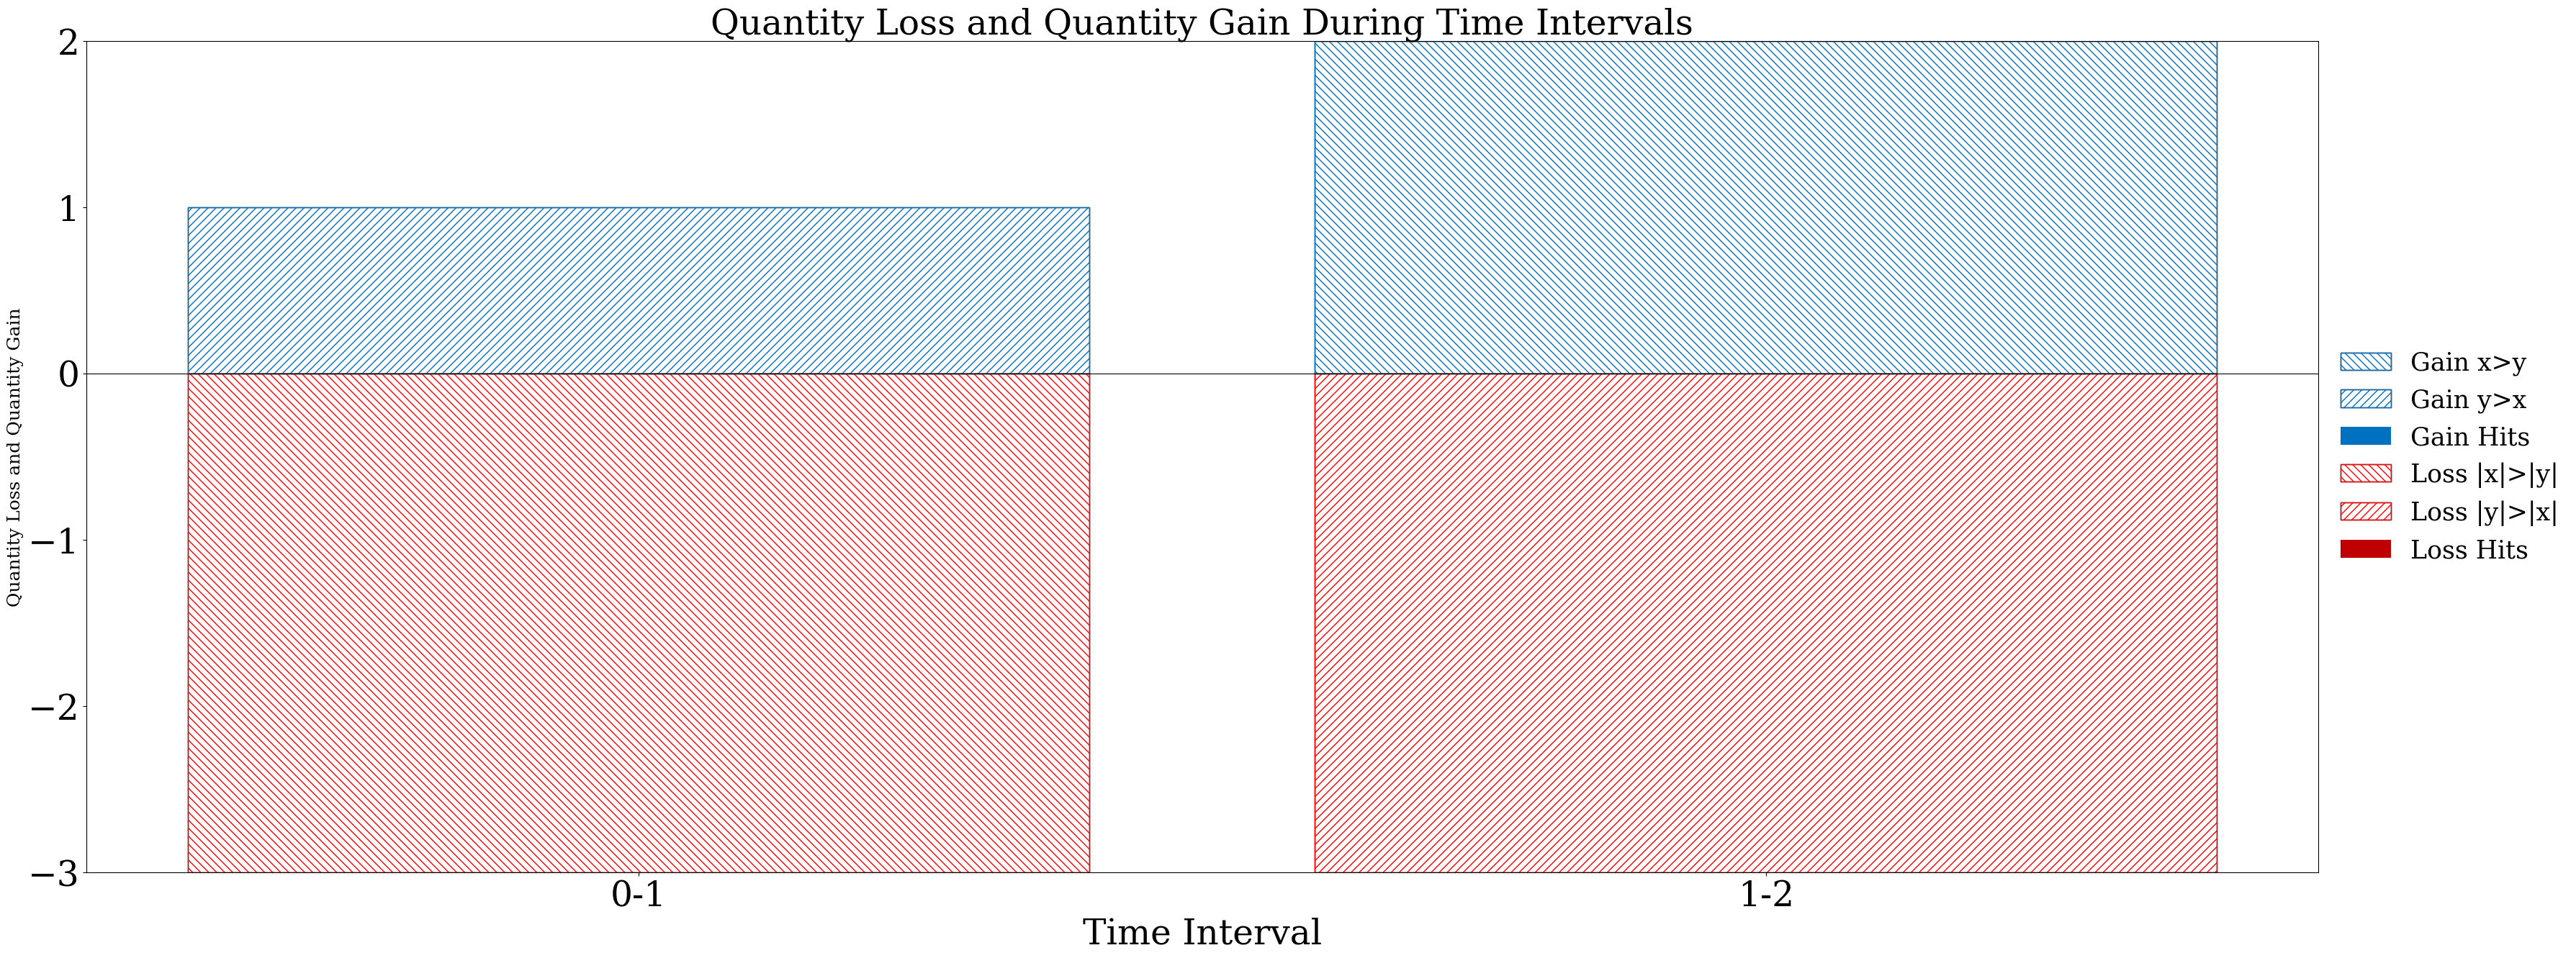


✅ Processing complete. Graphic saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata2/net_change_toyData.png


In [13]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
# net_plot_data_list = []

# for interval in time_intervals:
#     row_data = net_change_by_interval.get(interval, {})
#     row_data["Interval"] = interval
#     net_plot_data_list.append(row_data)

# sum_row_net = sum_net_results.copy()
# sum_row_net["Interval"] = "Sum"
# net_plot_data_list.append(sum_row_net)

# extent_row_net = net_extent_results.copy()
# extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
# net_plot_data_list.append(extent_row_net)

# df_plot_net = pd.DataFrame(net_plot_data_list).set_index("Interval").fillna(0)
# labels = df_plot_net.index.tolist()

# gain_colors = {
#     "Hits": "#0070C0",
#     "Time Difference": "#BDD7EE",
#     "Miss": "white",
#     "False Alarm": "white"
# }
# loss_colors = {
#     "Hits": "#C00000",
#     "Time Difference": "#FF9696",
#     "Miss": "white",
#     "False Alarm": "white"
# }
# gain_hatch_color = "#0070C0"
# loss_hatch_color = "#FF0000"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
net_plot_data_list = []

for interval in time_intervals:
    row_data = net_change_by_interval.get(interval, {})
    row_data["Interval"] = interval
    net_plot_data_list.append(row_data)

# continua guardando Sum e extent, caso precise em tabelas/exportações
sum_row_net = sum_net_results.copy()
sum_row_net["Interval"] = "Sum"
net_plot_data_list.append(sum_row_net)

extent_row_net = net_extent_results.copy()
extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
net_plot_data_list.append(extent_row_net)

# cria DataFrame
df_plot_net = pd.DataFrame(net_plot_data_list).set_index("Interval").fillna(0)

# remove 'Sum' e extent antes de gerar o gráfico
extent_label = f"{time_points[0]}-{time_points[-1]}"
df_plot_net = df_plot_net.drop(["Sum", extent_label], errors="ignore")

# labels para plotagem
labels = df_plot_net.index.tolist()


# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(40, 15)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# -----------------------------------------------------------------------------
# 1.4 Bars — Net Gains
# -----------------------------------------------------------------------------
bottom_gain = np.zeros(len(labels))

for comp in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    # final legend text (no post-remap needed)
    disp = (
        "x>y" if comp == "Miss"
        else ("y>x" if comp == "False Alarm" else comp)
    )

    data = df_plot_net[f"Gain {comp}"].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Gain {disp}",
            color=gain_colors[comp],
            bottom=bottom_gain,
            edgecolor="none"
        )
    bottom_gain += data

# -----------------------------------------------------------------------------
# 1.5 Bars — Net Losses
# -----------------------------------------------------------------------------
bottom_loss = np.zeros(len(labels))

for comp in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    # final legend text (no post-remap needed)
    disp = (
        "|x|>|y|" if comp == "Miss"
        else ("|y|>|x|" if comp == "False Alarm" else comp)
    )

    data = df_plot_net[f"Loss {comp}"].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Loss {disp}",
            color=loss_colors[comp],
            bottom=bottom_loss,
            edgecolor="none"
        )
    bottom_loss += data

# -----------------------------------------------------------------------------
# 1.6 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

# custom patches for hatched entries
legend_dict["Gain x>y"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="\\\\\\")
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="///")
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="\\\\\\")
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="///")
)

order = [
    "Gain x>y",
    "Gain y>x",
    # "Gain Time Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    # "Loss Time Difference",
    "Loss Hits"
]

ordered_handles = [legend_dict.get(label) for label in order if label in legend_dict]
ordered_labels  = [label for label in order if label in legend_dict]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=25,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

# -----------------------------------------------------------------------------
# 1.7 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Quantity Loss and Quantity Gain During Time Intervals",
    fontsize=35
)
ax.set_xlabel(
    "Time Interval",
    fontsize=35
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=35,
    rotation=0
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=35
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.autoscale(enable=False, axis="y")
# ax.set_ylim(-8, 14)
# ax.margins(y=0)
# ax.set_yticks(np.arange(-8, 14 + 1, 2))
ax.set_ylabel(
    "Quantity Loss and Quantity Gain",
    fontsize=18
)

# Option 2: For real data with large values
# def millions_formatter(y, pos):
#     return f"{y / 1_000_000:.0f}"

# ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
# # ax.set_ylim(
# #     -2_000_000,
# #      2_000_000
# # )
# ax.set_ylabel(
#     "Quantity Loss and Quantity Gain (million pixels)",
#     fontsize=30
# )

# Option 3: For real data with large values (thousand)
# def thousands_formatter(y, pos):
#     return f"{y / 1_000:.0f}"
# ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
# ax.set_ylim(-900_000, 900_000)
# ax.set_ylabel(
#     "Quantity Loss and Quantity Gain (thousand pixels)",
#     fontsize=20
# )

# =============================================================================
# 1.8 Save figure
# =============================================================================
output_filename = f"net_change_{class_name}.png"
final_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_path}")


##### 4.3.2 Sum and Extent


Plotting Net Change — only 'Sum' and 'Extent'...


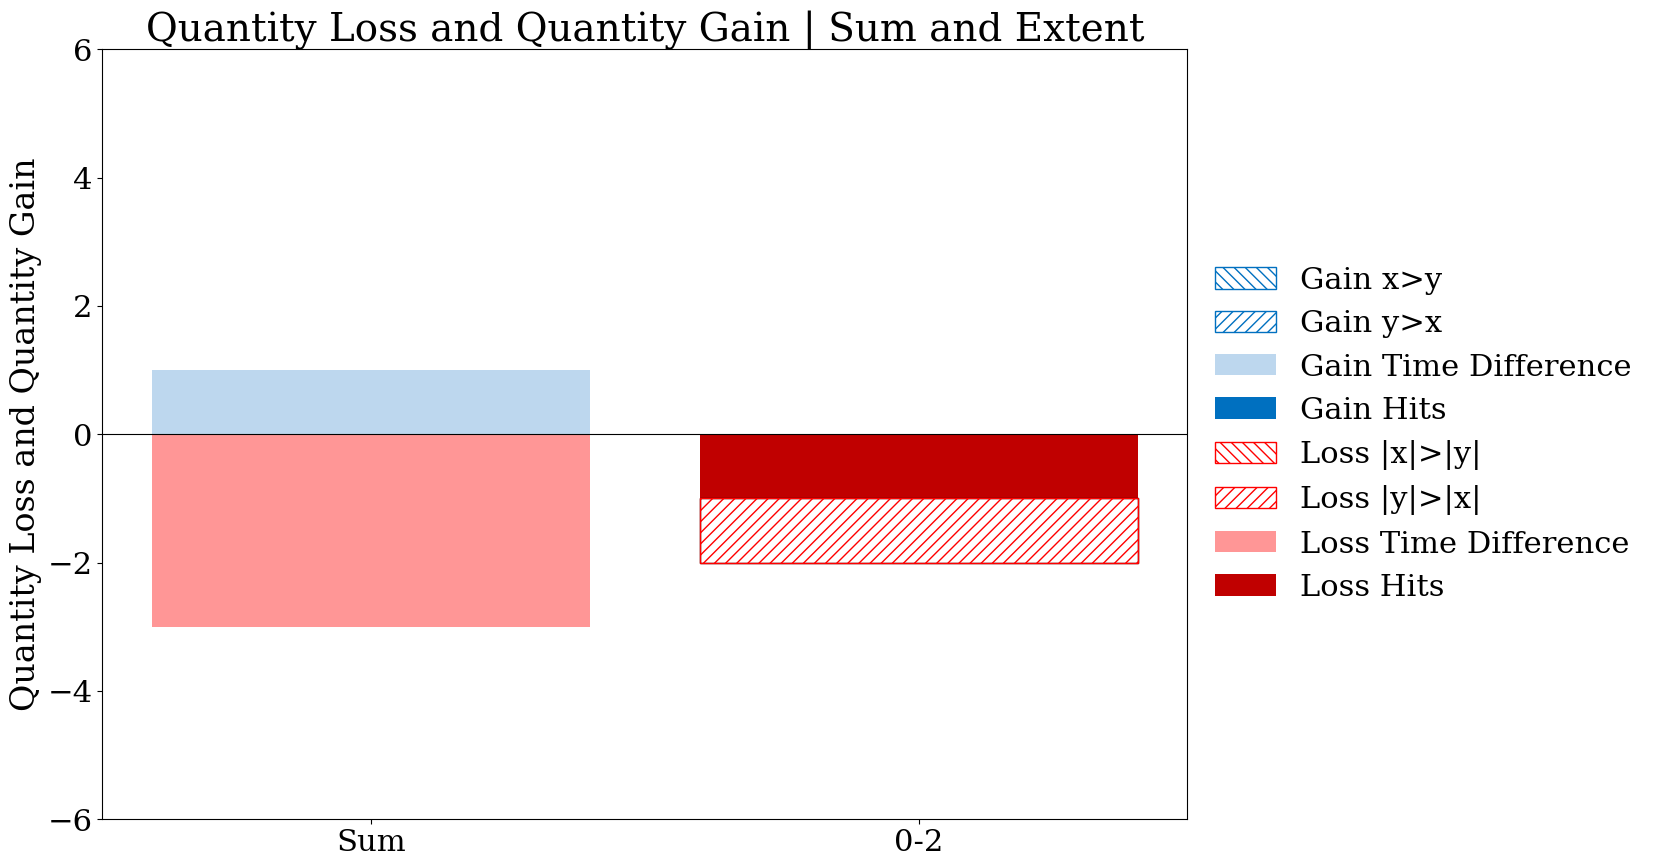


✅ Processing complete. Graphic saved as: /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata2/net_change_sum_extent_toyData.png


In [11]:
# =============================================================================
# 1. Making the graphic (Net Change — only "Sum" and "Extent")
# =============================================================================
print("\nPlotting Net Change — only 'Sum' and 'Extent'...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
# Fallback de cores, caso não estejam definidos anteriormente no notebook
if "gain_colors" not in globals():
    gain_colors = {
        "Hits":            "#0070C0",
        "Time Difference": "#BDD7EE",
        "Miss":            "white",
        "False Alarm":     "white",
    }
if "loss_colors" not in globals():
    loss_colors = {
        "Hits":            "#C00000",
        "Time Difference": "#FF9696",
        "Miss":            "white",
        "False Alarm":     "white",
    }
gain_hatch_color = globals().get("gain_hatch_color", "#0070C0")
loss_hatch_color = globals().get("loss_hatch_color", "#FF0000")

# Apenas as linhas "Sum" e "Extent" (primeiro-último ano)
extent_label = f"{time_points[0]}-{time_points[-1]}"

sum_row_net = dict(sum_net_results)
sum_row_net["Interval"] = "Sum"

extent_row_net = dict(net_extent_results)
extent_row_net["Interval"] = extent_label

df_plot_net_se = (
    pd.DataFrame([sum_row_net, extent_row_net])
      .set_index("Interval")
      .fillna(0)
)
labels_se = df_plot_net_se.index.tolist()

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(14, 10),
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

# -----------------------------------------------------------------------------
# 1.4 Bars — Net Gains
# -----------------------------------------------------------------------------
bottom_gain = np.zeros(len(labels_se))

for comp in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    disp = (
        "x>y" if comp == "Miss"
        else ("y>x" if comp == "False Alarm" else comp)
    )
    col_name = f"Gain {comp}"
    data = (
        df_plot_net_se[col_name].values
        if col_name in df_plot_net_se.columns
        else np.zeros(len(labels_se))
    )

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels_se,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black",
        )
        ax.bar(
            labels_se,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch,
        )
    else:
        ax.bar(
            labels_se,
            data,
            label=f"Gain {disp}",
            color=gain_colors.get(comp, "#cccccc"),
            bottom=bottom_gain,
            edgecolor="none",
        )

    bottom_gain += data

# -----------------------------------------------------------------------------
# 1.5 Bars — Net Losses
# -----------------------------------------------------------------------------
bottom_loss = np.zeros(len(labels_se))

for comp in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    disp = (
        "|x|>|y|" if comp == "Miss"
        else ("|y|>|x|" if comp == "False Alarm" else comp)
    )
    col_name = f"Loss {comp}"
    data = (
        df_plot_net_se[col_name].values
        if col_name in df_plot_net_se.columns
        else np.zeros(len(labels_se))
    )

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels_se,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black",
        )
        ax.bar(
            labels_se,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch,
        )
    else:
        ax.bar(
            labels_se,
            data,
            label=f"Loss {disp}",
            color=loss_colors.get(comp, "#f2aaaa"),
            bottom=bottom_loss,
            edgecolor="none",
        )

    bottom_loss += data

# -----------------------------------------------------------------------------
# 1.6 Legend Settings (single symbol for hatched entries)
# -----------------------------------------------------------------------------

handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

# Itens hachurados: um único Patch (sem HandlerTuple)
legend_dict["Gain x>y"] = mpatches.Patch(
    facecolor="white",
    edgecolor=gain_hatch_color,
    hatch="\\\\\\",
)
legend_dict["Gain y>x"] = mpatches.Patch(
    facecolor="white",
    edgecolor=gain_hatch_color,
    hatch="///",
)
legend_dict["Loss |x|>|y|"] = mpatches.Patch(
    facecolor="white",
    edgecolor=loss_hatch_color,
    hatch="\\\\\\",
)
legend_dict["Loss |y|>|x|"] = mpatches.Patch(
    facecolor="white",
    edgecolor=loss_hatch_color,
    hatch="///",
)

# Ordem, mantendo Time Difference na legenda
order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Time Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Time Difference",
    "Loss Hits",
]

ordered_handles = [
    legend_dict[label]
    for label in order
    if label in legend_dict
]
ordered_labels = [
    label
    for label in order
    if label in legend_dict
]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=22,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left",
)

# -----------------------------------------------------------------------------
# 1.7 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Quantity Loss and Quantity Gain | Sum and Extent",
    fontsize=28,
)

# ax.set_xlabel(
#     "Summary",
#     fontsize=24,
# )

ax.tick_params(
    axis="x",
    which="major",
    labelsize=22,
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=22,
)

# ax.yaxis.set_major_formatter(
#     FuncFormatter(lambda y, pos: f"{y / 1_000_000:.0f}"),
# )

ax.set_ylabel(
    "Quantity Loss and Quantity Gain",
    fontsize=24,
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================
# Option 1: autoscale
# ax.autoscale(enable=True, axis="y")

# Option 2: fixed limits for real data (uncomment if quiser padronizar escala)
ax.set_ylim(
    -6,
     6,
)

# =============================================================================
# 1.8 Save figure
# =============================================================================
out_name = f"net_change_sum_extent_{class_name}.png"
final_path = os.path.join(
    output_path,
    out_name,
)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    f"\n✅ Processing complete. Graphic saved as: {final_path}",
)

## 5. Export results

In [14]:
# =============================================================================
# 1. Export all graphic results to an Excel file
# =============================================================================
print("Starting the export of results to Excel...")

import pandas as pd

excel_filename = f"analysis_results_{class_name}.xlsx"
excel_final_path = os.path.join(
    output_path,
    excel_filename
)

with pd.ExcelWriter(excel_final_path, engine="xlsxwriter") as writer:

    # -----------------------------------------------------------------------------
    # ReadMe sheet
    # -----------------------------------------------------------------------------
    readme_text = (
        "This Excel file summarizes all results from the notebook.\n\n"
        "Sheet descriptions:\n\n"
        "- Presence Agreement:\n"
        "  Aggregated values for the Presence Agreement chart (Hits, Misses, etc.)\n"
        "  for each time point and the final sum.\n\n"
        "- Gross Change:\n"
        "  Values for the Gross Loss and Gain chart, showing all components of gross\n"
        "  change (including Space Difference) for each interval, the sum, and extent.\n\n"
        "- Net Change:\n"
        "  Values for the Net Change chart, showing quantity-based components of change\n"
        "  (without Space Difference) for each interval, the sum, and the extent."
    )
    df_readme = pd.DataFrame(
        {"File Description": [readme_text]}
    )
    df_readme.to_excel(
        writer,
        sheet_name="ReadMe",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Presence Agreement sheet
    # -----------------------------------------------------------------------------
    presence_data_list = []

    for tp in time_points:
        row_data = results_by_time.get(tp, {})
        row_data["Time Point"] = tp
        presence_data_list.append(row_data)

    sum_row_presence = sum_results.copy()
    sum_row_presence["Time Point"] = "Sum"
    presence_data_list.append(sum_row_presence)

    df_presence = pd.DataFrame(presence_data_list)

    presence_cols_order = [
        "Time Point",
        "Hit",
        "Space Difference",
        "Time Difference",
        "Miss",
        "False Alarm",
        "Total X",
        "Total Y"
    ]
    df_presence = (
        df_presence[presence_cols_order]
        .fillna(0)
    )

    df_presence.to_excel(
        writer,
        sheet_name="Presence Agreement",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Gross Change sheet
    # -----------------------------------------------------------------------------
    gross_change_data_list = []

    for interval in time_intervals:
        row_data = change_results_by_interval.get(interval, {})
        row_data["Interval"] = interval
        gross_change_data_list.append(row_data)

    sum_row_gross = sum_change_results.copy()
    sum_row_gross["Interval"] = "Sum"
    gross_change_data_list.append(sum_row_gross)

    extent_row_gross = extent_results.copy()
    extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
    gross_change_data_list.append(extent_row_gross)

    df_gross = pd.DataFrame(gross_change_data_list)

    gross_cols_order = [
        "Interval",
        "Gain Hits",
        "Gain Space Difference",
        "Gain Time Difference",
        "Gain Miss",
        "Gain False Alarm",
        "Loss Hits",
        "Loss Space Difference",
        "Loss Time Difference",
        "Loss Miss",
        "Loss False Alarm"
    ]
    df_gross = (
        df_gross[gross_cols_order]
        .fillna(0)
    )

    df_gross.to_excel(
        writer,
        sheet_name="Gross Change",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Net Change sheet
    # -----------------------------------------------------------------------------
    net_change_data_list = []

    for interval in time_intervals:
        row_data = net_change_by_interval.get(interval, {})
        row_data["Interval"] = interval
        net_change_data_list.append(row_data)

    sum_row_net = sum_net_results.copy()
    sum_row_net["Interval"] = "Sum"
    net_change_data_list.append(sum_row_net)

    extent_row_net = net_extent_results.copy()
    extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
    net_change_data_list.append(extent_row_net)

    df_net = pd.DataFrame(net_change_data_list)

    net_cols_order = [
        "Interval",
        "Gain Hits",
        "Gain Time Difference",
        "Gain Miss",
        "Gain False Alarm",
        "Loss Hits",
        "Loss Time Difference",
        "Loss Miss",
        "Loss False Alarm"
    ]
    df_net = (
        df_net[net_cols_order]
        .fillna(0)
    )

    df_net.to_excel(
        writer,
        sheet_name="Net Change",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Auto-adjust column widths
    # -----------------------------------------------------------------------------
    workbook = writer.book

    for sheet_name, df in {
        "ReadMe": df_readme,
        "Presence Agreement": df_presence,
        "Gross Change": df_gross,
        "Net Change": df_net
    }.items():

        worksheet = writer.sheets[sheet_name]

        if sheet_name == "ReadMe":
            worksheet.set_column("A:A", 80)
            cell_format = workbook.add_format(
                {"valign": "top", "text_wrap": True}
            )
            worksheet.set_row(0, 150, cell_format)
        else:
            for idx, col in enumerate(df.columns):
                series = df[col].astype(str)
                max_len = max(series.map(len).max(), len(str(col))) + 2
                worksheet.set_column(idx, idx, max_len)

print(f"\n✅ All results successfully exported to: {excel_final_path}")

Starting the export of results to Excel...

✅ All results successfully exported to: /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata2/analysis_results_toyData.xlsx


# 6. Maps

## 6.1 Equation 49

In [3]:
import os
import numpy as np
import rasterio

def equation_49_hit_sum(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Sum of minimum values (hits) between x and y over all time steps,
    applied to raster stacks (shape: time, height, width).
    Returns a 2D array (height, width).
    """
    hits = np.minimum(x, y)
    return np.sum(hits, axis=0)

# Read all rasters in the folder, sorted by time_points
def read_rast_stack(folder_path, time_points):
    rasters = []
    for t in time_points:
        filename = os.path.join(folder_path, f"{class_name}{t}.tif")
        with rasterio.open(filename) as src:
            rasters.append(src.read(1))
    return np.stack(rasters, axis=0)  # shape (time, height, width)

# Paths and variables you provided
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/x"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/y"
time_points = [0, 1, 2]
class_name = "toyData"
output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Read raster stacks
x_stack = read_rast_stack(path_series_x, time_points)
y_stack = read_rast_stack(path_series_y, time_points)

# Apply function
result = equation_49_hit_sum(x_stack, y_stack)

# Use metadata from one input raster to build output
with rasterio.open(os.path.join(path_series_x, f"{class_name}{time_points[0]}.tif")) as src0:
    meta = src0.meta.copy()
    meta.update(count=1, dtype=result.dtype)

# Write output raster
output_file = os.path.join(output_path, "Equation49_result.tif")
with rasterio.open(output_file, 'w', **meta) as dst:
    dst.write(result, 1)

print(f"Output raster saved to {output_file}")


Output raster saved to /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3/Equation49_result.tif


## 6.2 Equation 50

In [6]:
import os
import numpy as np
import rasterio

def equation_50_difference_sum(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    For raster time series stacks: x and y have shape (T+1, height, width)
    Returns: np.ndarray, shape (height, width), sum of (y - x) over time
    """
    # Calculate difference at each time for each pixel
    diff = y - x
    # Sum over time axis (axis=0)
    bn = np.sum(diff, axis=0)
    return bn

def read_rast_stack(folder_path, time_points, class_name):
    rasters = []
    for t in time_points:
        filename = os.path.join(folder_path, f"{class_name}{t}.tif")
        with rasterio.open(filename) as src:
            rasters.append(src.read(1))
    return np.stack(rasters, axis=0)  # shape (time, height, width)

# Paths and variables you provided
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/x"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/y"
time_points = [0, 1, 2]
class_name = "toyData"
output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Read raster stacks
x_stack = read_rast_stack(path_series_x, time_points, class_name)
y_stack = read_rast_stack(path_series_y, time_points, class_name)

# Apply function
result = equation_50_difference_sum(x_stack, y_stack)

# Use metadata from one input raster to build output
with rasterio.open(os.path.join(path_series_x, f"{class_name}{time_points[0]}.tif")) as src0:
    meta = src0.meta.copy()
    meta.update(count=1, dtype=result.dtype)

# Write output raster
output_file = os.path.join(output_path, "Equation50_result.tif")
with rasterio.open(output_file, 'w', **meta) as dst:
    dst.write(result, 1)

print(f"Output raster saved to {output_file}")


Output raster saved to /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3/Equation50_result.tif


## 6.3 Equation 51

In [7]:
import os
import numpy as np
import rasterio

def equation_51_temporal_allocation_difference(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    For raster time series stacks: x and y have shape (T+1, height, width)
    Returns: np.ndarray, shape (height, width), temporal allocation difference for each pixel.
    Implements Equation 51: sum of absolute differences over time minus absolute difference of total sums.
    """
    # Calculate difference at each time for each pixel
    diff = y - x
    # Sum of absolute differences over time for each pixel
    abs_diff_sum = np.sum(np.abs(diff), axis=0)
    # Total sum over time for each pixel
    total_y = np.sum(y, axis=0)
    total_x = np.sum(x, axis=0)
    # Absolute difference of total sums for each pixel
    bn = np.abs(total_y - total_x)
    # Equation 51: abs_diff_sum - bn
    cn = abs_diff_sum - bn
    return cn

def read_rast_stack(folder_path, time_points, class_name):
    rasters = []
    for t in time_points:
        filename = os.path.join(folder_path, f"{class_name}{t}.tif")
        with rasterio.open(filename) as src:
            rasters.append(src.read(1))
    return np.stack(rasters, axis=0)  # shape (time, height, width)

# Paths and variables you provided
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/x"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/y"
time_points = [0, 1, 2]
class_name = "toyData"
output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Read raster stacks
x_stack = read_rast_stack(path_series_x, time_points, class_name)
y_stack = read_rast_stack(path_series_y, time_points, class_name)

# Apply function
result = equation_51_temporal_allocation_difference(x_stack, y_stack)

# Use metadata from one input raster to build output
with rasterio.open(os.path.join(path_series_x, f"{class_name}{time_points[0]}.tif")) as src0:
    meta = src0.meta.copy()
    meta.update(count=1, dtype=result.dtype)

# Write output raster
output_file = os.path.join(output_path, "Equation51_result.tif")
with rasterio.open(output_file, 'w', **meta) as dst:
    dst.write(result, 1)

print(f"Output raster saved to {output_file}")


Output raster saved to /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3/Equation51_result.tif


## 6.4 Equation 52

In [ ]:
import os
import numpy as np
import rasterio

def equation_52_change_hits_raster(x, y):
    dx = x[1:, ...] - x[:-1, ...]  # shape: (T, H, W)
    dy = y[1:, ...] - y[:-1, ...]  # shape: (T, H, W)

    # Loss hit: ambos negativos, pega o máximo (mais próximo de zero, ainda negativo)
    loss_hit = np.where((dx < 0) & (dy < 0), np.maximum(dx, dy), 0)
    # Gain hit: ambos positivos, pega o mínimo (menor positivo)
    gain_hit = np.where((dx > 0) & (dy > 0), np.minimum(dx, dy), 0)

    # Soma dos hits de ganho menos a soma dos hits de perda para cada pixel
    dn = np.sum(gain_hit - loss_hit, axis=0).astype(np.int16)
    return dn

def read_rast_stack(folder_path, time_points, class_name):
    rasters = []
    for t in time_points:
        filename = os.path.join(folder_path, f"{class_name}{t}.tif")
        with rasterio.open(filename) as src:
            arr = src.read(1)
            rasters.append(arr)
            print(f"Time {t}, pixel [0,0]: {arr[0,0]}")  # Debug
    return np.stack(rasters, axis=0)

# Paths and variables
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/x"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/y"
time_points = [0, 1, 2]
class_name = "toyData"
output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3"
if not os.path.exists(output_path):
    os.makedirs(output_path)

x_stack = read_rast_stack(path_series_x, time_points, class_name)
y_stack = read_rast_stack(path_series_y, time_points, class_name)

result = equation_52_change_hits_raster(x_stack, y_stack)

with rasterio.open(os.path.join(path_series_x, f"{class_name}{time_points[0]}.tif")) as src0:
    meta = src0.meta.copy()
    meta.update(count=1, dtype=result.dtype)

output_file = os.path.join(output_path, "Equation52_result.tif")
with rasterio.open(output_file, 'w', **meta) as dst:
    dst.write(result, 1)

print(f"Output raster saved to {output_file}")

Time 0, pixel [0,0]: 2
Time 1, pixel [0,0]: 0
Time 2, pixel [0,0]: 5
Time 0, pixel [0,0]: 4
Time 1, pixel [0,0]: 1
Time 2, pixel [0,0]: 0
x_stack[:,0,0]: [2 0 5]
y_stack[:,0,0]: [4 1 0]


CPLE_AppDefinedError: Deleting /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3/Equation52_result.tif failed: Permission denied

## 6.5 Equation 53

In [11]:
import os
import numpy as np
import rasterio

def equation_53_extent_difference(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    For raster time series stacks: x and y have shape (T+1, height, width)
    Returns: np.ndarray, shape (height, width), extent difference for each pixel.
    Implements Equation 53: (y_last - y_first) - (x_last - x_first) for each pixel.
    """
    # Calculate change from first to last time point for each pixel
    delta_y = y[-1, ...] - y[0, ...]
    delta_x = x[-1, ...] - x[0, ...]
    # Equation 53: extent difference
    en = delta_y - delta_x
    return en

def read_rast_stack(folder_path, time_points, class_name):
    rasters = []
    for t in time_points:
        filename = os.path.join(folder_path, f"{class_name}{t}.tif")
        with rasterio.open(filename) as src:
            rasters.append(src.read(1))
    return np.stack(rasters, axis=0)  # shape (time, height, width)

# Paths and variables you provided
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/x"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/y"
time_points = [0, 1, 2]
class_name = "toyData"
output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Read raster stacks
x_stack = read_rast_stack(path_series_x, time_points, class_name)
y_stack = read_rast_stack(path_series_y, time_points, class_name)

# Apply function
result = equation_53_extent_difference(x_stack, y_stack)

# Use metadata from one input raster to build output
with rasterio.open(os.path.join(path_series_x, f"{class_name}{time_points[0]}.tif")) as src0:
    meta = src0.meta.copy()
    meta.update(count=1, dtype=result.dtype)

# Write output raster
output_file = os.path.join(output_path, "Equation53_result.tif")
with rasterio.open(output_file, 'w', **meta) as dst:
    dst.write(result, 1)

print(f"Output raster saved to {output_file}")


Output raster saved to /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3/Equation53_result.tif


## 6.6 Equation 54

In [12]:
import os
import numpy as np
import rasterio

def equation_53_extent_difference(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    Implements Equation 53 for raster stacks: (y_last - y_first) - (x_last - x_first)
    """
    delta_y = y[-1, ...] - y[0, ...]
    delta_x = x[-1, ...] - x[0, ...]
    en = delta_y - delta_x
    return en

def equation_54_flexibility_difference(
    x: np.ndarray,
    y: np.ndarray
) -> np.ndarray:
    """
    For raster time series stacks: x and y have shape (T+1, height, width)
    Returns: np.ndarray, shape (height, width), flexibility difference for each pixel.
    Implements Equation 54: sum over time of abs((y_t - y_{t-1}) - (x_t - x_{t-1})) minus abs(En)
    """
    # Calculate transitions for y and x
    dy = y[1:, ...] - y[:-1, ...]
    dx = x[1:, ...] - x[:-1, ...]
    # Difference of transitions, per time step and pixel
    abs_diff_transition = np.abs(dy - dx)
    # Sum over all time steps for each pixel
    sum_abs_diff = np.sum(abs_diff_transition, axis=0)
    # Calculate En using Equation 53
    en = equation_53_extent_difference(x, y)
    # Equation 54: Fn = summed transitions difference - |En|
    fn = sum_abs_diff - np.abs(en)
    return fn

def read_rast_stack(folder_path, time_points, class_name):
    rasters = []
    for t in time_points:
        filename = os.path.join(folder_path, f"{class_name}{t}.tif")
        with rasterio.open(filename) as src:
            rasters.append(src.read(1))
    return np.stack(rasters, axis=0)  # shape (time, height, width)

# Paths and variables you provided
path_series_x = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/x"
path_series_y = r"/mnt/c/Users/AntFonseca/github/1.INPUT/compare-time-series/toydata2/y"
time_points = [0, 1, 2]
class_name = "toyData"
output_path = r"/mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Read raster stacks
x_stack = read_rast_stack(path_series_x, time_points, class_name)
y_stack = read_rast_stack(path_series_y, time_points, class_name)

# Apply function
result = equation_54_flexibility_difference(x_stack, y_stack)

# Use metadata from one input raster to build output
with rasterio.open(os.path.join(path_series_x, f"{class_name}{time_points[0]}.tif")) as src0:
    meta = src0.meta.copy()
    meta.update(count=1, dtype=result.dtype)

# Write output raster
output_file = os.path.join(output_path, "Equation54_result.tif")
with rasterio.open(output_file, 'w', **meta) as dst:
    dst.write(result, 1)

print(f"Output raster saved to {output_file}")

Output raster saved to /mnt/c/Users/AntFonseca/github/2.OUTPUT/toydata3/Equation54_result.tif
